<>:51: SyntaxWarning: invalid escape sequence '\|'
<>:52: SyntaxWarning: invalid escape sequence '\|'
<>:53: SyntaxWarning: invalid escape sequence '\|'
<>:54: SyntaxWarning: invalid escape sequence '\|'
<>:65: SyntaxWarning: invalid escape sequence '\O'
<>:95: SyntaxWarning: invalid escape sequence '\i'
<>:51: SyntaxWarning: invalid escape sequence '\|'
<>:52: SyntaxWarning: invalid escape sequence '\|'
<>:53: SyntaxWarning: invalid escape sequence '\|'
<>:54: SyntaxWarning: invalid escape sequence '\|'
<>:65: SyntaxWarning: invalid escape sequence '\O'
<>:95: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_45300/3946360427.py:51: SyntaxWarning: invalid escape sequence '\|'
  ax1.loglog(h, err_w, 'o-', label='$\|\sigma_h-\sigma\|_{L^2(\Omega)}$', color='#d62728', linewidth=2, markersize=6)
/tmp/ipykernel_45300/3946360427.py:52: SyntaxWarning: invalid escape sequence '\|'
  ax1.loglog(h, err_u, 's-', label='$\|\eta_h-\eta\|_{L^2(\Omega)}$', color='#2ca02c', linewidth=2, mark

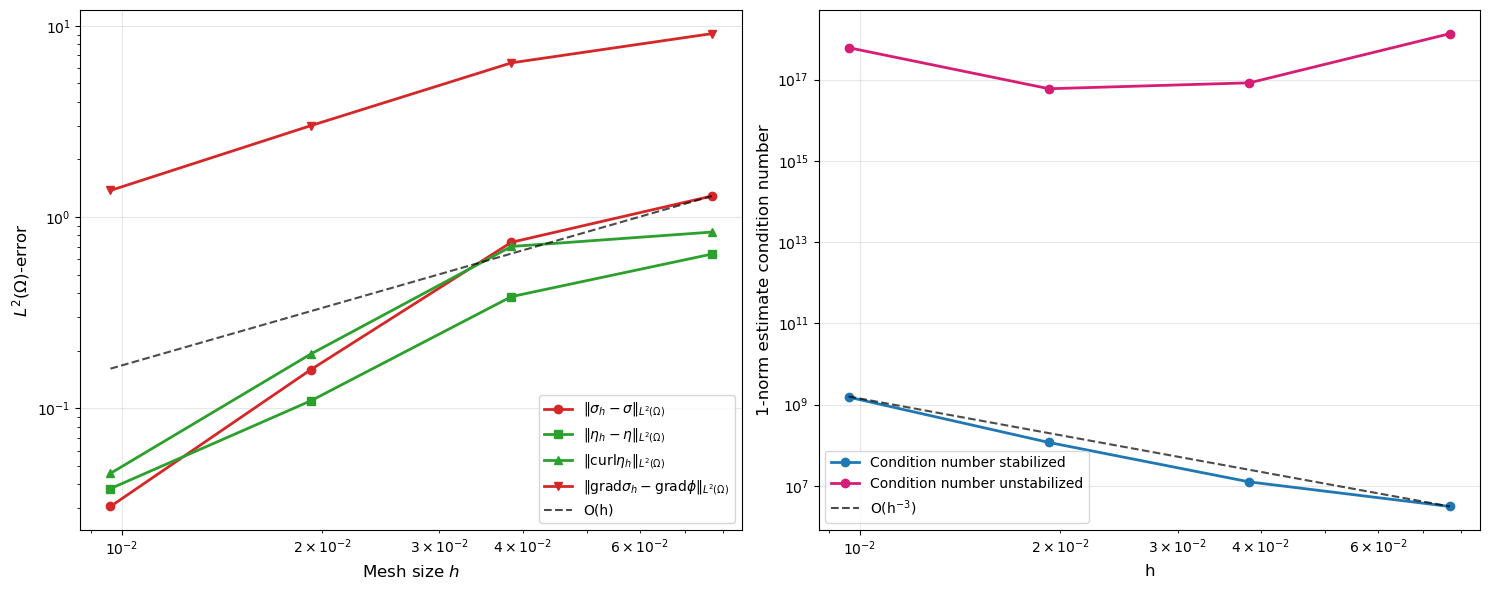

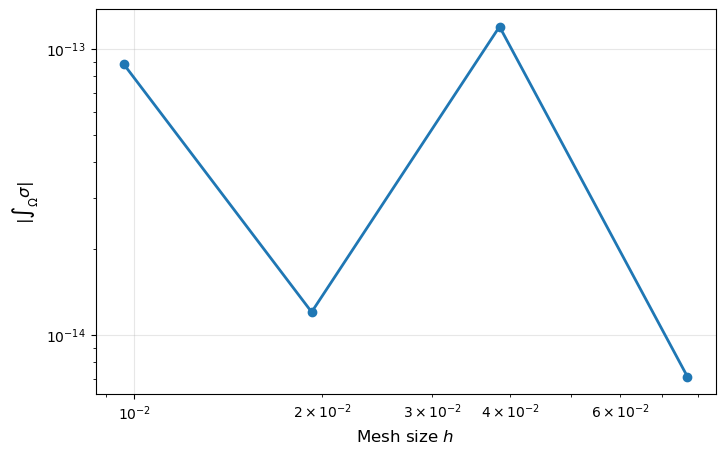

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the file
h = np.array([
0.076923 , 
0.038462 , 
0.019231 , 
0.0096154])
err_w = np.array([
1.2865  , 
0.7371  , 
0.15903 ,
0.030568])
err_u = np.array([
0.63945 , 
0.38296 , 
0.10924 , 
0.037901])
err_curlu = np.array([
0.83361 , 
0.70072 , 
0.19198 , 
0.045558])
err_gradw = np.array([
9.1038 , 
6.4024 , 
3.0059 , 
1.3763])
mean_w = np.array([
-7.1367e-15, 
-1.1941e-13, 
-1.2003e-14, 
-8.8244e-14])
norm_cond_nbr = np.array([
3.08E+06,
1.24E+07,
1.16E+08,
1.52E+09])
norm_cond_nbr_unstab = np.array([
1.36E+18,
8.36E+16,
5.98E+16,
6.14E+17])


# Create two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Error measurements with O(h) reference line
ax1.loglog(h, err_w, 'o-', label='$\|\sigma_h-\sigma\|_{L^2(\Omega)}$', color='#d62728', linewidth=2, markersize=6)
ax1.loglog(h, err_u, 's-', label='$\|\eta_h-\eta\|_{L^2(\Omega)}$', color='#2ca02c', linewidth=2, markersize=6)
ax1.loglog(h, err_curlu, '^-', label='$\|\mathrm{curl} \eta_h\|_{L^2(\Omega)}$', color='#2ca02c', linewidth=2, markersize=6)
ax1.loglog(h, err_gradw, 'v-', label='$\|\mathrm{grad} \sigma_h - \mathrm{grad} \phi\|_{L^2(\Omega)}$', color='#d62728', linewidth=2, markersize=6)

# Add O(h) reference line
# Scale the reference line to fit nicely with the data
h_ref = np.array([h.min(), h.max()])
# Use err_w as reference for scaling
ref_scale = err_w[0] / h[0]  # Scale factor to match first data point of err_w
oh_ref = ref_scale * h_ref
ax1.loglog(h_ref, oh_ref, '--', color='black', alpha=0.7, linewidth=1.5, label='O(h)')

ax1.set_xlabel('Mesh size $h$', fontsize=12)
ax1.set_ylabel('$L^2(\Omega)$-error', fontsize=12)
# ax1.set_title('Error Measurements vs h', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Condition number with O(h^{-2}) reference line
ax2.loglog(h, norm_cond_nbr, 'o-', label='Condition number stabilized', color='#1f77b4', linewidth=2, markersize=6)
ax2.loglog(h, norm_cond_nbr_unstab, 'o-', label='Condition number unstabilized', color="#d71c76", linewidth=2, markersize=6)


# Add O(h^{-2}) reference line
# Scale the reference line to fit with the condition number data
ref_scale_cond = norm_cond_nbr[0] * h[0]**3  # Scale factor
oh2_ref = ref_scale_cond / (h_ref**3)
ax2.loglog(h_ref, oh2_ref, '--', color='black', alpha=0.7, linewidth=1.5, label='O(h$^{-3}$)')

ax2.set_xlabel('h', fontsize=12)
ax2.set_ylabel('1-norm estimate condition number', fontsize=12)
# ax2.set_title('1-norm Condition Number vs h', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../post-subm-with-error-analysis/figure/error_and_condition_plots.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Optional: Plot mean w separately (if needed)
plt.figure(figsize=(8, 5))
plt.loglog(h, np.abs(mean_w), 'o-', color='#1f77b4', linewidth=2, markersize=6)
plt.xlabel('Mesh size $h$', fontsize=12)
plt.ylabel('$|\int_\Omega \sigma|$', fontsize=12)
# plt.title('Absolute Mean w vs h', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('../post-subm-with-error-analysis/figure/mean_w_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()